# IT2011 — 2026-Y2-S1-KU-02
# Member 1: Nawarathna H.M.L.C. (IT25100124)
## Technique: Handling Missing Data

**Why it's needed for this dataset:** Even though MNIST is a curated benchmark, no dataset should be assumed
clean without verification — this is a mandatory first check before any further preprocessing, and the
"no missing data" finding itself needs to be demonstrated and documented rather than assumed. For image data, we also check a related
data-validity issue alongside the standard missing-value check: completely blank (all-zero) images. Strictly
speaking these are not "missing" in the statistical sense (a value is present, not absent) — they are closer to
a corrupted/invalid sample. We check for them here, next to the missing-value check, for completeness and
because they would carry no usable signal for a classifier, but we're flagging the terminology distinction
explicitly rather than treating the two as identical.


## Setup

This notebook is self-contained: it loads MNIST itself and reproduces any minimal prerequisite steps from a
teammate's earlier pipeline stage (noted where relevant), so it can be run and presented standalone in the
Progress Review I viva.


In [ ]:

# Install TensorFlow if it is not already available in the current Python environment.
# This ensures that the required TensorFlow/Keras libraries are available when the notebook
# is shared and executed on another computer or in a different Python environment.
%pip install tensorflow

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from tensorflow.keras.datasets import mnist

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Training images:", X_train.shape, "| Training labels:", y_train.shape)
print("Test images:    ", X_test.shape,  "| Test labels:    ", y_test.shape)


Training images: (60000, 28, 28) | Training labels: (60000,)
Test images:     (10000, 28, 28) | Test labels:     (10000,)


In [2]:
print("Checking for NaN (missing) values...")
nan_train_images = np.isnan(X_train).sum()
nan_test_images = np.isnan(X_test).sum()
nan_train_labels = np.isnan(y_train.astype('float64')).sum()
nan_test_labels = np.isnan(y_test.astype('float64')).sum()

blank_train = int(np.sum(X_train.reshape(X_train.shape[0], -1).sum(axis=1) == 0))
blank_test = int(np.sum(X_test.reshape(X_test.shape[0], -1).sum(axis=1) == 0))

missing_summary = pd.DataFrame({
    "Check": ["NaN pixel values", "NaN labels", "Completely blank (all-zero) images"],
    "Training set": [nan_train_images, nan_train_labels, blank_train],
    "Test set": [nan_test_images, nan_test_labels, blank_test]
})
missing_summary


Checking for NaN (missing) values...


,Check,Training set,Test set
0,NaN pixel values,0,0
1,NaN labels,0,0
2,Completely blank (all-zero) images,0,0


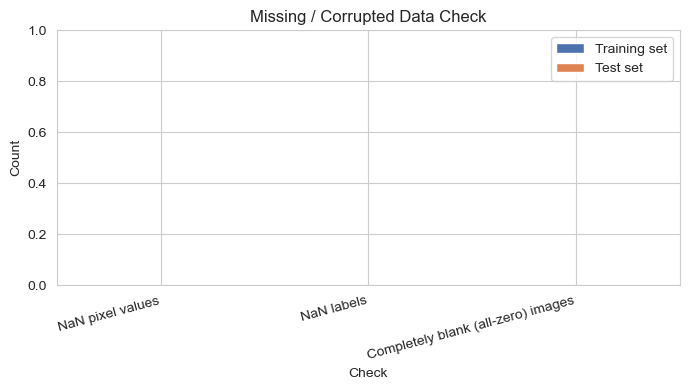

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
missing_summary.set_index("Check")[["Training set", "Test set"]].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title("Missing / Corrupted Data Check")
ax.set_ylabel("Count")
ax.set_ylim(0, max(1, missing_summary[["Training set", "Test set"]].values.max() * 1.5))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/01_missing_data_check.png', bbox_inches='tight')
plt.show()


**Interpretation:** All counts are zero — MNIST contains no `NaN` pixel values, no missing labels, and no
completely blank/invalid images (checked here as a data-validity companion check, distinct from missing-value handling) in either the training or test split. No imputation, row-dropping, or interpolation is
required. This is documented explicitly rather than assumed, since "the dataset was already clean" is itself a
result of a preprocessing check, not a shortcut around one.
